In [1]:
import os, glob
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
import pandas as pd

In [2]:
%matplotlib widget

In [3]:
# from tiled.client import from_profile, from_uri
# tiled_client = from_profile('pdf')

## Load mask files as numpy array for PDF data

In [4]:
mask_dir = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/config_base/pilatus_PDF/'
masks_pos_flist = ['Mask_pos1_ext_BS.npy', 'Mask_pos2_ext_BS.npy', 'Mask_pos3_ext_BS.npy']
# masks_pos_fn = ['Mask_pos1_ext_BS.npy', 'Mask_pos2_ext_BS.npy', 'Mask_pos3_ext_BS.npy']
m1_path = os.path.join(mask_dir, masks_pos_flist[0])
m2_path = os.path.join(mask_dir, masks_pos_flist[1])
m3_path = os.path.join(mask_dir, masks_pos_flist[2])
use_mask_1= np.load(m1_path)  # This is mask we are applying befor mergin images
use_mask_2 = np.load(m2_path) # This is mask we are applying befor mergin images
use_mask_3 = np.load(m3_path) # This is mask we are applying befor mergin images

## Define the function for normalization and stitching

In [5]:
def normalize_stitch(pilatus_tiff_list, osetx = 27, osety = 27):

    my_im1 = np.float32(io.imread(pilatus_tiff_list[2]))
    my_im2 = np.float32(io.imread(pilatus_tiff_list[1]))
    my_im3 = np.float32(io.imread(pilatus_tiff_list[0]))
    
    my_imsum = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

    my_imsum[osetx:-osetx, osety:-osety, 0] = my_im1
    my_imsum[osetx:-osetx, osety:-osety, 0][use_mask_3==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

    my_imsum[:-int(2*osetx), :-int(2*osety):, 1] = my_im2
    my_imsum[:-int(2*osetx), :-int(2*osety):, 1][use_mask_2==1] = np.nan

    my_imsum[int(2*osetx):, int(2*osety):, 2] = my_im3
    my_imsum[int(2*osetx):, int(2*osety):, 2][use_mask_1==1] = np.nan  ##order of mask updated by CHL on 2025/11/03

    # img_mean = np.nanmean(my_imsum, axis=2, dtype=np.float32)
    
    my_imsum_nor = np.ones((my_im1.shape[0]+int(2*osetx), my_im2.shape[1]+int(2*osety),3))*np.nan

    for i in range(my_imsum.shape[2]):
        my_imsum_nor[:, :, i] = my_imsum[:, :, i] / np.nanmean(my_imsum[:, :, i])

    img_mean_nor = np.nanmean(my_imsum_nor, axis=2, dtype=np.float32)
    
    return img_mean_nor
    

## Load PDF data from tiff_base in the proposal folder

In [ ]:
tiff_base = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/'
pdf_folders = glob.glob(os.path.join(tiff_base, '**pdf**'))
pdf_folders

## Read pdf tiff files from dark_sub folder, do normalization, stitching, and save data

In [ ]:
nn = 0
for sample_path in pdf_folders[0:]:
    _tiff = os.path.join(sample_path, 'dark_sub', '**pilatus**pos**.tiff')
    pilatus_tiff_list = glob.glob(_tiff)
    pilatus_tiff_list.sort()
    # print(*pilatus_tiff_list, sep='\n')
    
    num_pdf = int(len(pilatus_tiff_list)/3)
    for i in range(num_pdf):
        img_mean_nor = normalize_stitch(pilatus_tiff_list[i*3:i*3+3])
        sample_info = os.path.basename(pilatus_tiff_list[i*3])
        idx = sample_info.find('pilatus')
        fn_prefix = f'{sample_info[:idx+len("pilatus")]}_normalized.tiff'
        
        fn_path = os.path.join(sample_path, fn_prefix)
        io.imsave(fn_path, img_mean_nor)
        
        nn += 1
    

In [ ]:
nn

## Load XRD data from tiff_base in the proposal folder

In [ ]:
tiff_base = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/'
pdf_folders = glob.glob(os.path.join(tiff_base, '**xrd**'))
pdf_folders

## Read xrd tiff files from dark_sub folder, do normalization, stitching, and save data

In [ ]:
nn = 0
for sample_path in pdf_folders[0:]:
    _tiff = os.path.join(sample_path, 'dark_sub', '**pilatus**pos**.tiff')
    pilatus_tiff_list = glob.glob(_tiff)
    pilatus_tiff_list.sort()
    # print(*pilatus_tiff_list, sep='\n')
    
    num_pdf = int(len(pilatus_tiff_list)/3)
    for i in range(num_pdf):
        img_mean_nor = normalize_stitch(pilatus_tiff_list[i*3:i*3+3])
        sample_info = os.path.basename(pilatus_tiff_list[i*3])
        idx = sample_info.find('pilatus')
        fn_prefix = f'{sample_info[:idx+len("pilatus")]}_normalized.tiff'
        
        fn_path = os.path.join(sample_path, fn_prefix)
        io.imsave(fn_path, img_mean_nor)
        
        nn += 1
    

In [ ]:
nn

## Percentile integration

In [6]:
import pyFAI
import numpy.ma as ma

## Load poni files and mask for PDF data

In [ ]:
poni_fn = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/CeO2_pdf/CeO2_pdf_20251103-115741_8f9cc5_pilatus_normalized.poni'
pyfai_ai = pyFAI.load(poni_fn)
npt_rad = 4096
npt_azim = 360*2
polarization = 0.99
UNIT = "2th_deg" #'q_A^-1'
low_limit_pcfilter = 10
up_limit_pcfilter = 90

mask_fn = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/config_base/pilatus_PDF/Mask_stitched.npy'
mask_array = np.load(mask_fn)

## Define a function to save 1d I(q) data

In [7]:
def iq_saver(fn, df, md, header=['q_A^-1', 'I(q)']):
    
    with open(fn, mode='w', encoding='utf-8') as f:
        f.write('pyFai_poni_information_28ID1_NSLS2_BNL\n')
        num_row = 1
        for key, value in md.items():
            f.write(f'{key} {value}\n')
            num_row += 1
    
    ## Now append the dataframe
    df.to_csv(fn, encoding='utf-8', mode='a', header=header, index=False, float_format='{:.8e}'.format, sep=' ')

    ## return the number of rows of the header
    return num_row

## Define a function for pyFAI integration 

In [45]:
def pct_integration(img, ai, 
                    iq_fn = '',
                    npt_rad=npt_rad, 
                    unit=UNIT, 
                    npt_azim=npt_azim,                  
                    polarization_factor=polarization, 
                    mask=mask_array):

    ## perform azimuthalintegration on one image to retain 2D information
    ## i2d.shape is (self.npt_azim, self.npt_rad) which corresponds the intensity of 2D image cake
    ## q1d.shape is (self.npt_rad, )
    i2d, q1d, chi1d = ai.integrate2d(img, npt_rad, 
                                     unit=UNIT, npt_azim=npt_azim, 
                                     polarization_factor=polarization, 
                                     mask=mask_array) 

    ## trasnform self.mask_array (base mask) to the same coordinate space and cast it as type bool
    intrinsic_mask_unrolled, _, _ = ai.integrate2d(mask_array, npt_rad, 
                                                   unit=UNIT, npt_azim=npt_azim, 
                                                   polarization_factor=polarization, 
                                                   mask=mask_array)
    #intrinsic_mask_unrolled = intrinsic_mask_unrolled.astype(bool) 

    ## Create an array to hold outlier mask
    outlier_mask_2d = np.zeros_like(i2d)     
    mask1 = np.array(i2d<0)*1   ## change to i2d<0 for normalized-stitched tiff on 2025/11/04

    ## Apply percentile filter along radial direction (axis=0)
    if low_limit_pcfilter >= 0:
        for ii, dd in enumerate(i2d.T):
            low_limit, high_limit = np.percentile(dd, (low_limit_pcfilter, up_limit_pcfilter))
            outlier_mask_2d[:,ii] = np.any([dd<low_limit, dd>high_limit, intrinsic_mask_unrolled[:,ii]], axis=0)

        outlier_mask_2d_masked = ma.masked_array(i2d, mask=outlier_mask_2d + mask1)
        
    elif low_limit_pcfilter < 0:
        outlier_mask_2d_masked = ma.masked_array(i2d, mask=mask1)

    ## calculate mean values along radial direction (axis=0) to make i1d.shape is (self.npt_rad, )
    i1d = ma.mean(outlier_mask_2d_masked, axis=0)

    iq_df0 = pd.DataFrame()
    iq_df0['q'] = q1d
    iq_df0['I'] = i1d
    # iq_df = iq_df0.dropna()
    iq_df = iq_df0.fillna(0)

    md = ai.getPyFAI()
    # _md = {'detector': self.run.start['detectors'][0], 
    #        'uid':self.full_uid, 
    #        'time': self.run.start['time'], 
    #        'readable_time': self.readable_time, 
    #        'percentile_low_limit': self.ll, 
    #        'percentile_up_limit': self.ul, 
    #        self.T_controller: self.temperature, 
    # }
    _md = {}
    md.update(_md)

    ## num_row will be the number of rows of the header in saved iq data file
    
    if 'q' in unit:
        header=['q_A^-1', 'I(q)']
        
    elif '2th' in unit:
        header=['2th_deg', 'I(2th)']
    
    num_rows_header = iq_saver(iq_fn, iq_df, md, header=header)
    print(f'\n*** {os.path.basename(iq_fn)} saved!! ***\n')

    return iq_df, iq_fn, outlier_mask_2d_masked

## Load normalized-stitched pdf tiff files for integration

In [ ]:
tiff_base = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/'
nor_pdf_tiffs = glob.glob(os.path.join(tiff_base, '**pdf**', '**normalized.tiff'))
len(nor_pdf_tiffs)

In [ ]:
plt.figure()
for tiff_fn in nor_pdf_tiffs[0:]:
    img = io.imread(tiff_fn)
    iq_fn =tiff_fn[:-4] + 'tth'
    # print(iq_fn)
    
    iq_df, _, _ = pct_integration(img, pyfai_ai, 
                                  iq_fn=iq_fn, 
                                  npt_rad=npt_rad, 
                                  unit=UNIT, 
                                  npt_azim=npt_azim, 
                                  polarization_factor=polarization, 
                                  mask=mask_array)
    
    plt.plot(iq_df.iloc[:, 0], iq_df.iloc[:, 1])


## Load poni files and mask for XRD data

In [46]:
poni_fn = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/CeO2_xrd/CeO2_xrd_20251103-120612_a3395d_pilatus_normalized.poni'
pyfai_ai = pyFAI.load(poni_fn)
npt_rad = 4096
npt_azim = 360*2
polarization = 0.99
UNIT = "2th_deg" #'q_A^-1'
low_limit_pcfilter = 10
up_limit_pcfilter = 90

mask_fn = '/nsls2/data3/pdf/pdfhack/legacy/processed/xpdacq_data/user_data/config_base/pilatus_XRD/Mask_stitched.npy'
mask_array = np.load(mask_fn)

In [47]:
pyfai_ai.get_config()

{'poni_version': 2.1,
 'dist': 1.0003634494189435,
 'poni1': 0.03984843327829884,
 'poni2': 0.16844922155187675,
 'rot1': -0.0021846712228448463,
 'rot2': 0.002693258055032374,
 'rot3': 0.0,
 'detector': 'Detector',
 'detector_config': {'pixel1': 0.00017199999999999998,
  'pixel2': 0.00017199999999999998,
  'max_shape': (1733, 1529),
  'orientation': <Orientation.BottomRight: 3>},
 'wavelength': 1.6650000000000002e-11}

## Load normalized-stitched xrd tiff files for integration

In [48]:
tiff_base = '/nsls2/data/pdf/proposals/2025-3/pass-318908/White_317310_a82c91dc/tiff_base/'
nor_pdf_tiffs = glob.glob(os.path.join(tiff_base, '**xrd**', '**normalized.tiff'))
len(nor_pdf_tiffs)

48


*** CeO2_xrd_20251103-120536_ec0fb1_pilatus_normalized.tth saved!! ***


*** CeO2_xrd_20251103-120612_a3395d_pilatus_normalized.tth saved!! ***


*** HM_xrd_20251103-132048_312511_pilatus_normalized.tth saved!! ***


*** HM_xrd_20251103-153540_d29e9d_pilatus_normalized.tth saved!! ***


*** DHM_xrd_20251103-132108_e6ee22_pilatus_normalized.tth saved!! ***


*** DHM_xrd_20251103-153906_2d9549_pilatus_normalized.tth saved!! ***


*** MgO_xrd_20251103-132127_2dc153_pilatus_normalized.tth saved!! ***


*** MgO_xrd_20251103-154231_853c0c_pilatus_normalized.tth saved!! ***


*** SF_xrd_20251103-132146_46309d_pilatus_normalized.tth saved!! ***


*** SF_xrd_20251103-154557_7d7884_pilatus_normalized.tth saved!! ***


*** SHMP_xrd_20251103-132206_315a16_pilatus_normalized.tth saved!! ***


*** SHMP_xrd_20251103-154922_4bf0b2_pilatus_normalized.tth saved!! ***


*** MgO_SF_1_xrd_20251103-132225_89a707_pilatus_normalized.tth saved!! ***


*** MgO_SF_1_xrd_20251103-155248_cef7a0_pilatus_normalized

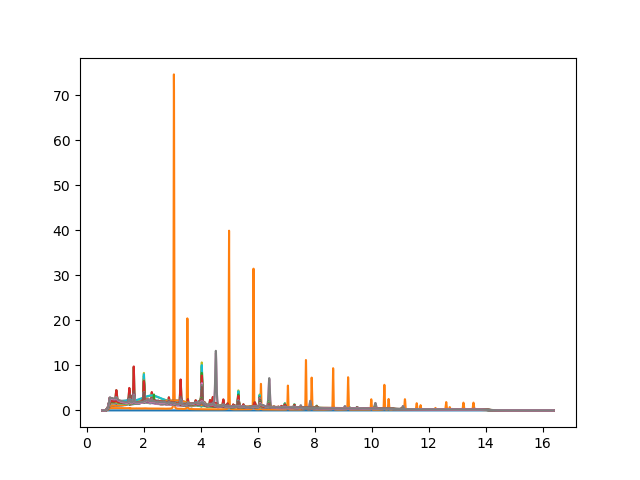

In [49]:
plt.figure()
for tiff_fn in nor_pdf_tiffs[0:]:
    img = io.imread(tiff_fn)
    iq_fn =tiff_fn[:-4] + 'tth'
    # print(iq_fn)
    
    iq_df, _, _ = pct_integration(img, pyfai_ai, 
                                  iq_fn=iq_fn, 
                                  npt_rad=npt_rad, 
                                  unit=UNIT, 
                                  npt_azim=npt_azim, 
                                  polarization_factor=polarization, 
                                  mask=mask_array)
    
    plt.plot(iq_df.iloc[:, 0], iq_df.iloc[:, 1])


In [44]:
# plt.figure()
# plt.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))

In [ ]:
# nrows = 2
# ncols = int((my_imsum.shape[2]+1)/2)
# f1 = plt.figure(figsize=(8, 5*nrows))

# for i in range(0, my_imsum.shape[2]+1):
#     ax1 = f1.add_subplot(nrows, ncols, i+1)
    
#     try:
#         img = my_imsum[:, :, i]
#     except IndexError:
#         img = img_mean
    
#     # ax1.imshow(img, vmin=np.nanpercentile(img, 10), vmax=np.nanpercentile(img, 98))
#     total_cnts = np.nansum(img)
#     ax1.imshow(img, vmin=1000, vmax=9000)
#     ax1.set_title(f'{total_cnts = }')
    
# f1.tight_layout()